# TP4 — Binary Prediction of Smoker Status using Bio-Signals
### Abordagem: XGBoost (Ensemble com Boosting + Bagging de Seeds/Folds)

**MO443 — Introdução à Inteligência Artificial**

Este notebook implementa a abordagem de **árvores de decisão com boosting (XGBoost)** para o desafio Kaggle [Playground Series S3E24](https://www.kaggle.com/competitions/playground-series-s3e24).

Usa apenas as **colunas originais da competição** (sem feature engineering — testamos e o
desempenho ficou pior, então essa versão foi descartada). O ganho de robustez vem da combinação
de duas estratégias de ensemble:

- **Boosting**: dentro de cada XGBoost, as árvores são construídas sequencialmente, cada uma
  corrigindo o erro da anterior.
- **Bagging**: por fora, treinamos 15 modelos independentes (3 seeds × 5 folds) e agregamos
  (média) suas previsões, reduzindo variância.

Pipeline: EDA enxuta → seleção de features (raw) → tuning de hiperparâmetros com Optuna →
treino final com bagging de folds/seeds → avaliação (OOF) → interpretabilidade (feature
importance + SHAP) → submissão → comparação com o leaderboard.


## 1. Setup e imports

In [1]:
# Descomente se precisar instalar no ambiente de execução
!pip install kagglehub xgboost optuna shap scikit-learn pandas numpy matplotlib seaborn -q


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


In [3]:
# Configurações gerais do experimento
N_SPLITS_CV = 5          # folds para avaliação final (CV completo)
N_SPLITS_OPTUNA = 3       # folds mais leves usados dentro do tuning (velocidade)
N_TRIALS_OPTUNA = 60      # número de trials do Optuna
SEEDS_BAGGING = [42, 202, 2026]   # seeds usadas no ensemble final
EARLY_STOPPING_ROUNDS = 100
N_ESTIMATORS_MAX = 3000   # teto alto; early stopping decide o número real


## 2. Carregamento dos dados

In [4]:
# Baixa (ou reutiliza cache local) os arquivos oficiais da competição
DATA_DIR = kagglehub.competition_download("playground-series-s3e24")
print("Path to competition files:", DATA_DIR)
print("Arquivos disponíveis:", os.listdir(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
sample_submission = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)

train.head()


Path to competition files: /kaggle/input/competitions/playground-series-s3e24
Arquivos disponíveis: ['sample_submission.csv', 'train.csv', 'test.csv']
train: (159256, 24)
test: (106171, 23)
sample_submission: (106171, 2)


,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,55,165,60,81.0,0.5,0.6,1,1,135,87,94,172,300,40,75,16.5,1,1.0,22,25,27,0,1
1,1,70,165,65,89.0,0.6,0.7,2,2,146,83,147,194,55,57,126,16.2,1,1.1,27,23,37,1,0
2,2,20,170,75,81.0,0.4,0.5,1,1,118,75,79,178,197,45,93,17.4,1,0.8,27,31,53,0,1
3,3,35,180,95,105.0,1.5,1.2,1,1,131,88,91,180,203,38,102,15.9,1,1.0,20,27,30,1,0
4,4,30,165,60,80.5,1.5,1.0,1,1,121,76,91,155,87,44,93,15.4,1,0.8,19,13,17,0,1


In [5]:
# Checagens básicas (já sabemos que não há nulos/duplicatas, mas confirmamos no notebook)
print("Nulos no train:", train.isna().sum().sum())
print("Nulos no test:", test.isna().sum().sum())
print("Duplicatas no train (ignorando id):", train.drop(columns=["id"]).duplicated().sum())
print()
print("Balanceamento do target:")
print(train["smoking"].value_counts(normalize=True))


Nulos no train: 0
Nulos no test: 0
Duplicatas no train (ignorando id): 0

Balanceamento do target:
smoking
0    0.562635
1    0.437365
Name: proportion, dtype: float64


## 3. EDA enxuta

Só o essencial para entender a separação das classes nas variáveis mais relevantes.


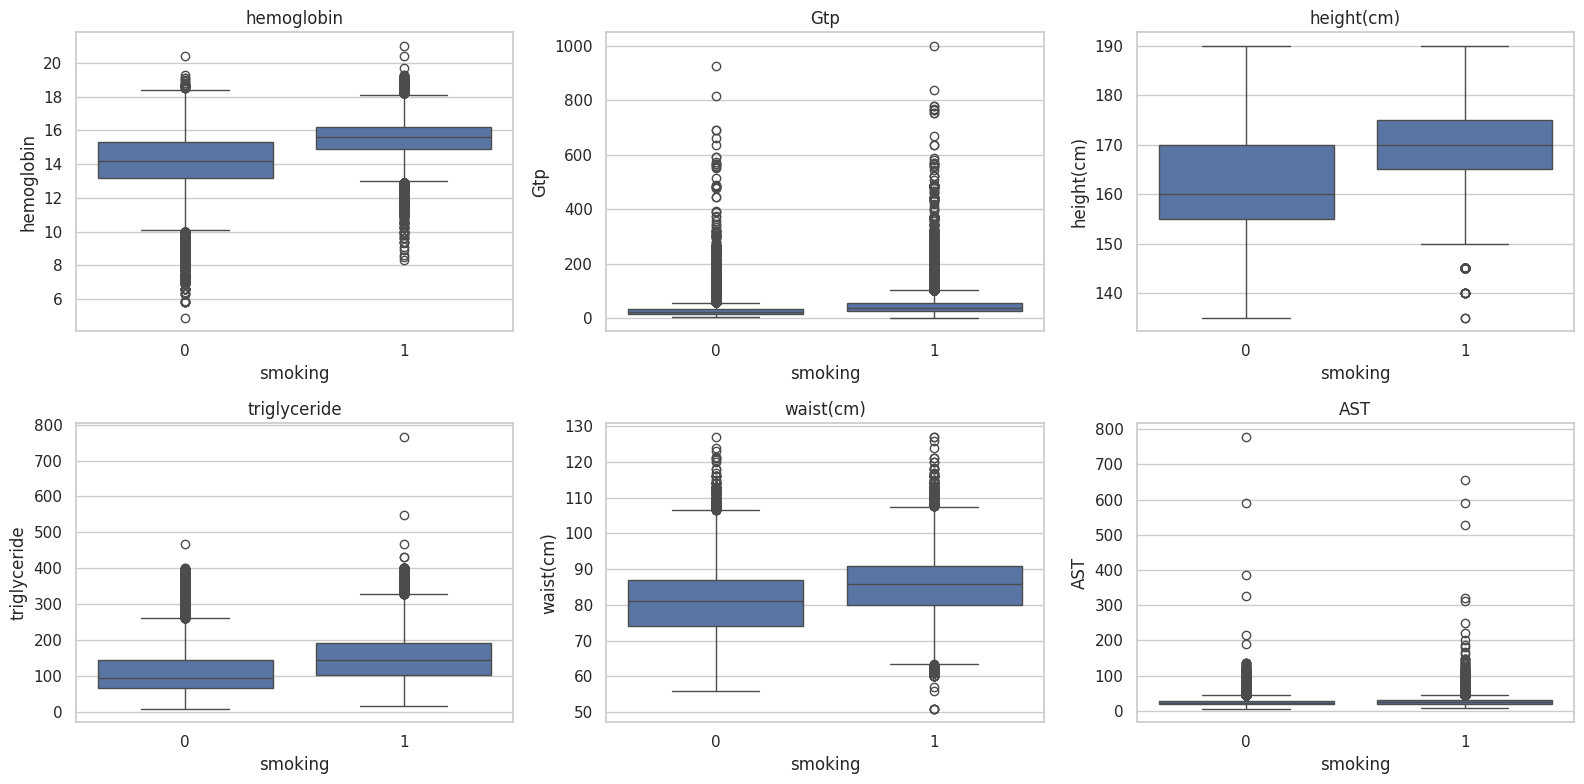

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
features_to_plot = ["hemoglobin", "Gtp", "height(cm)", "triglyceride", "waist(cm)", "AST"]

for ax, feat in zip(axes.ravel(), features_to_plot):
    sns.boxplot(data=train, x="smoking", y=feat, ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()


In [7]:
# Distribuição do valor sentinela em eyesight (9.9 aparenta ser "não mensurável / cego")
print("Valores únicos > 5 em eyesight(left):", sorted(train.loc[train['eyesight(left)'] > 5, 'eyesight(left)'].unique()))
print("Contagem de sentinela (>=9.0) em eyesight(left):", (train['eyesight(left)'] >= 9.0).sum())
print("Contagem de sentinela (>=9.0) em eyesight(right):", (train['eyesight(right)'] >= 9.0).sum())


Valores únicos > 5 em eyesight(left): [np.float64(9.9)]
Contagem de sentinela (>=9.0) em eyesight(left): 132
Contagem de sentinela (>=9.0) em eyesight(right): 117


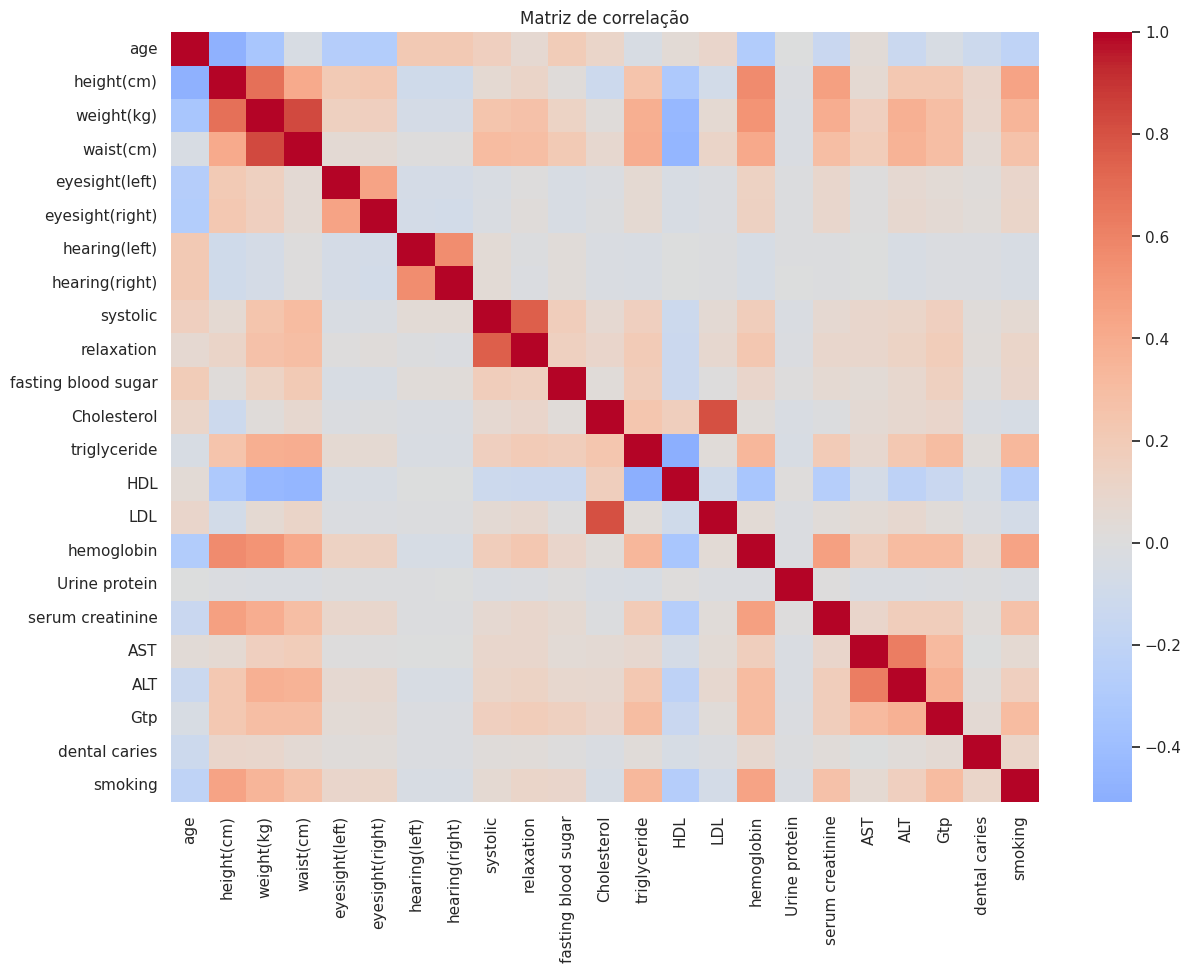

In [8]:
# Matriz de correlação (visão geral, sem remover nada — XGBoost tolera colinearidade)
plt.figure(figsize=(14, 10))
corr = train.drop(columns=["id"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlação")
plt.show()


## 4. Seleção de features

Usamos apenas as colunas originais da competição — mesma base que os outros dois modelos do
grupo (Regressão Logística e SSL+finetuning) usam. Isso garante uma comparação justa entre as
3 abordagens, variando só o algoritmo/paradigma.

(A versão com feature engineering foi testada à parte e teve desempenho levemente pior, então
foi descartada — não faz parte deste notebook.)


In [9]:
TARGET_COL = "smoking"
FEATURE_COLS = [c for c in train.columns if c not in ["id", TARGET_COL]]

X = train[FEATURE_COLS]
y = train[TARGET_COL]
X_test = test[FEATURE_COLS]

print(f"Número de features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Número de features: 22
['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries']


## 5. Configuração base do XGBoost

In [10]:
BASE_XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    device="cuda",   # comente esta linha se não houver GPU disponível no ambiente
    n_estimators=N_ESTIMATORS_MAX,
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


## 6. Tuning de hiperparâmetros (Optuna)

O objective usa `N_SPLITS_OPTUNA` folds (mais leve, por velocidade). A avaliação final (seção 8)
usa `N_SPLITS_CV` folds completos com os melhores hiperparâmetros encontrados aqui.


In [11]:
def tune_hyperparameters(X, y, label, n_trials=N_TRIALS_OPTUNA):
    """Busca de hiperparâmetros via Optuna, usando CV reduzida (N_SPLITS_OPTUNA) por velocidade."""

    def objective(trial):
        params = {
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        }

        skf = StratifiedKFold(n_splits=N_SPLITS_OPTUNA, shuffle=True, random_state=RANDOM_STATE)
        fold_aucs = []

        for train_idx, val_idx in skf.split(X, y):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

            model = XGBClassifier(**BASE_XGB_PARAMS, **params)
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            proba = model.predict_proba(X_va)[:, 1]
            fold_aucs.append(roc_auc_score(y_va, proba))

        return float(np.mean(fold_aucs))

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name=f"xgb_{label}",
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"[{label}] Melhor AUC (CV reduzida): {study.best_value:.5f}")
    print(f"[{label}] Melhores hiperparâmetros: {study.best_params}")

    return study


study_raw = tune_hyperparameters(X, y, label="raw")
best_params = study_raw.best_params


[I 2026-07-07 20:44:46,342] A new study created in memory with name: xgb_raw


  0%|          | 0/60 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:44:48] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[I 2026-07-07 20:44:51,460] Trial 0 finished with value: 0.8662223015035434 and parameters: {'max_depth': 5, 'learning_rate': 0.08927180304353628, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'min_child_weight': 4, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676}. Best is trial 0 with value: 0.8662223015035434.
[I 2026-07-07 20:44:58,356] Trial 1 finished with value: 0.8687834103788711 and parameters: {'max_depth': 7, 'learning_rate': 0.051059032093947576, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 17, 'reg_lambda': 0.0070689749506246055, 'reg_alpha': 0.005337032762603957, 'gamma': 0.9170225492671691}. Best is trial 1 with value: 0.8687834103788711.
[I 2026-07-07 20:45:12,610] Trial 2 finished with value: 0.87057572880325 and parameters: {'max_depth': 5, 'learning_rate': 0.03347776308515933, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.716491656079216

/tmp/ipykernel_58/3616186043.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_raw)


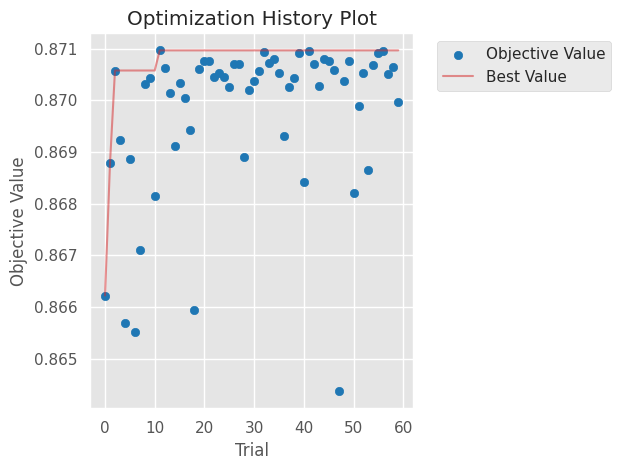

/tmp/ipykernel_58/3616186043.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study_raw)


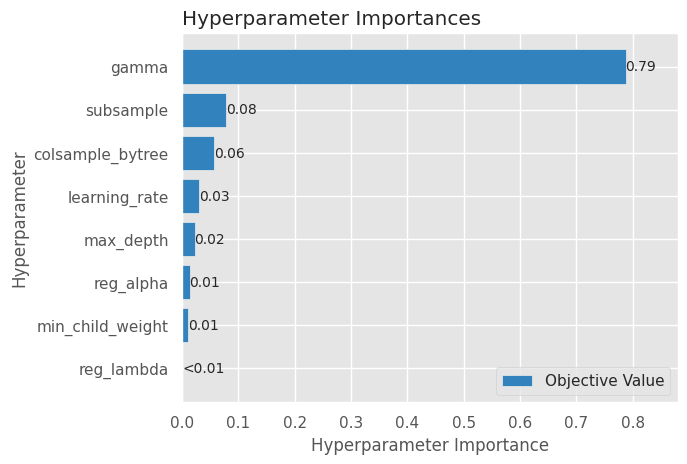

In [12]:
# Visualização do processo de otimização (bom material para o relatório)
optuna.visualization.matplotlib.plot_optimization_history(study_raw)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study_raw)
plt.show()


## 7. Treino final: bagging de folds e seeds

Treinamos um modelo por (fold × seed) usando os melhores hiperparâmetros do Optuna. A previsão
final é a **média das probabilidades** de todos os 15 modelos (3 seeds × 5 folds) — tanto para
a estimativa OOF (validação) quanto para o `test.csv` (submissão).


In [13]:
def train_bagged_ensemble(X, y, X_test, best_params, label):
    """Treina um modelo por (fold x seed) e retorna oof AUC, predições de teste e os modelos."""
    fold_models = []
    oof_predictions = np.zeros(len(X))
    test_predictions = np.zeros(len(X_test))
    n_models = 0

    for seed in SEEDS_BAGGING:
        skf = StratifiedKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=seed)

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
            X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

            model = XGBClassifier(**{**BASE_XGB_PARAMS, **best_params, "random_state": seed})
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

            val_proba = model.predict_proba(X_va)[:, 1]
            auc = roc_auc_score(y_va, val_proba)
            print(f"[{label}] Seed {seed} | Fold {fold_idx} | AUC = {auc:.5f}")

            # Média das 3 seeds: cada seed particiona todo o dataset em folds,
            # então cada linha recebe uma contribuição de cada seed (nunca do mesmo
            # modelo que a usou para treinar) -> consistente com o bagging do teste.
            oof_predictions[val_idx] += val_proba / len(SEEDS_BAGGING)

            test_predictions += model.predict_proba(X_test)[:, 1]
            fold_models.append(model)
            n_models += 1

    test_predictions /= n_models
    oof_auc = roc_auc_score(y, oof_predictions)
    print(f"[{label}] AUC out-of-fold final: {oof_auc:.5f} (n_modelos={n_models})")

    return {
        "fold_models": fold_models,
        "oof_predictions": oof_predictions,
        "test_predictions": test_predictions,
        "oof_auc": oof_auc,
        "n_models": n_models,
    }


results = train_bagged_ensemble(X, y, X_test, best_params, label="raw")


[raw] Seed 42 | Fold 0 | AUC = 0.87000
[raw] Seed 42 | Fold 1 | AUC = 0.87426
[raw] Seed 42 | Fold 2 | AUC = 0.87152
[raw] Seed 42 | Fold 3 | AUC = 0.87051
[raw] Seed 42 | Fold 4 | AUC = 0.87310
[raw] Seed 202 | Fold 0 | AUC = 0.87390
[raw] Seed 202 | Fold 1 | AUC = 0.87178
[raw] Seed 202 | Fold 2 | AUC = 0.87115
[raw] Seed 202 | Fold 3 | AUC = 0.86992
[raw] Seed 202 | Fold 4 | AUC = 0.87237
[raw] Seed 2026 | Fold 0 | AUC = 0.87228
[raw] Seed 2026 | Fold 1 | AUC = 0.87017
[raw] Seed 2026 | Fold 2 | AUC = 0.87286
[raw] Seed 2026 | Fold 3 | AUC = 0.87244
[raw] Seed 2026 | Fold 4 | AUC = 0.87128
[raw] AUC out-of-fold final: 0.87285 (n_modelos=15)


## 8. Avaliação

AUC out-of-fold (bagging completo, 15 modelos): 0.87285


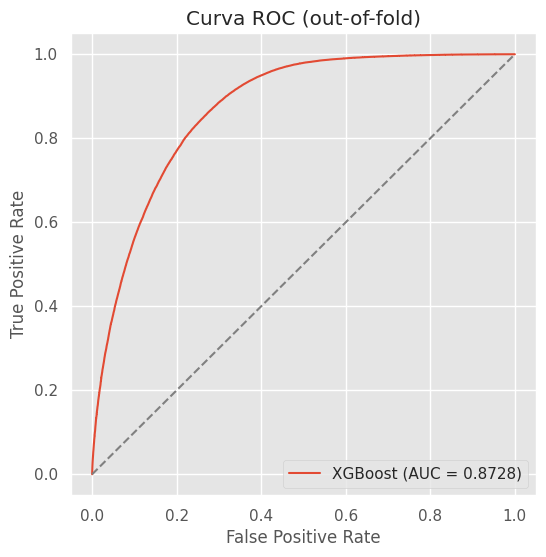

In [14]:
oof_auc = results["oof_auc"]
print(f"AUC out-of-fold (bagging completo, 15 modelos): {oof_auc:.5f}")

fpr, tpr, _ = roc_curve(y, results["oof_predictions"])
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {oof_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC (out-of-fold)")
plt.legend()
plt.show()


In [16]:
# Resumo para a tabela comparativa do relatório (XGBoost vs Regressão Logística vs SSL+finetuning)
summary = pd.DataFrame({
    "modelo": ["XGBoost (tuned + bagging de folds/seeds)"],
    "auc_oof": [oof_auc],
    "n_features": [len(FEATURE_COLS)],
    "n_modelos_ensemble": [results["n_models"]],
})
summary


,modelo,auc_oof,n_features,n_modelos_ensemble
0,XGBoost (tuned + bagging de folds/seeds),0.87285,22,15


## 9. Interpretabilidade

Feature importance nativa (gain) + SHAP para entender direção do efeito de cada bio-sinal.


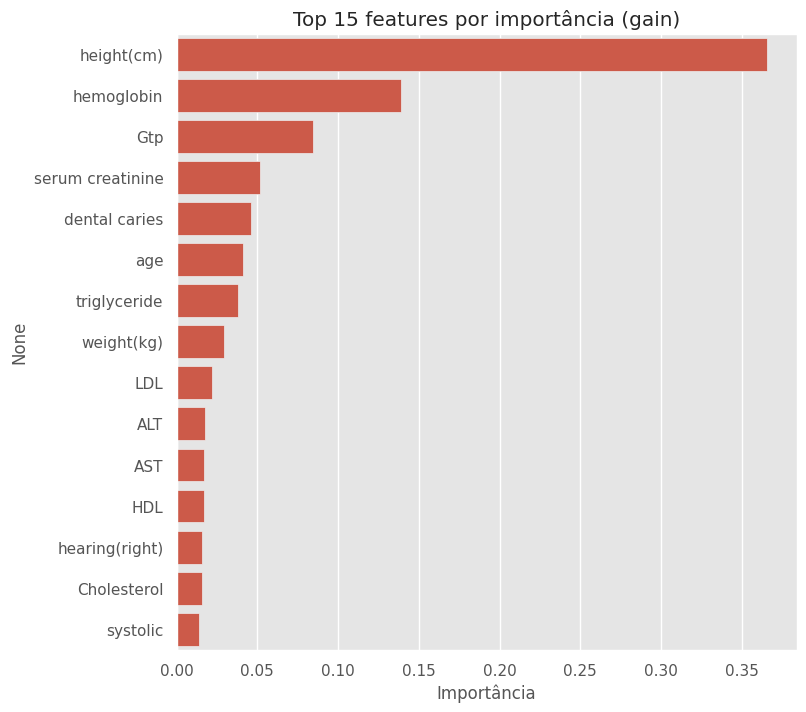

In [17]:
# Feature importance (gain) do último modelo treinado, como referência
importance_model = results["fold_models"][-1]

importances = pd.Series(
    importance_model.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title("Top 15 features por importância (gain)")
plt.xlabel("Importância")
plt.show()


/tmp/ipykernel_58/38039851.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, show=True)


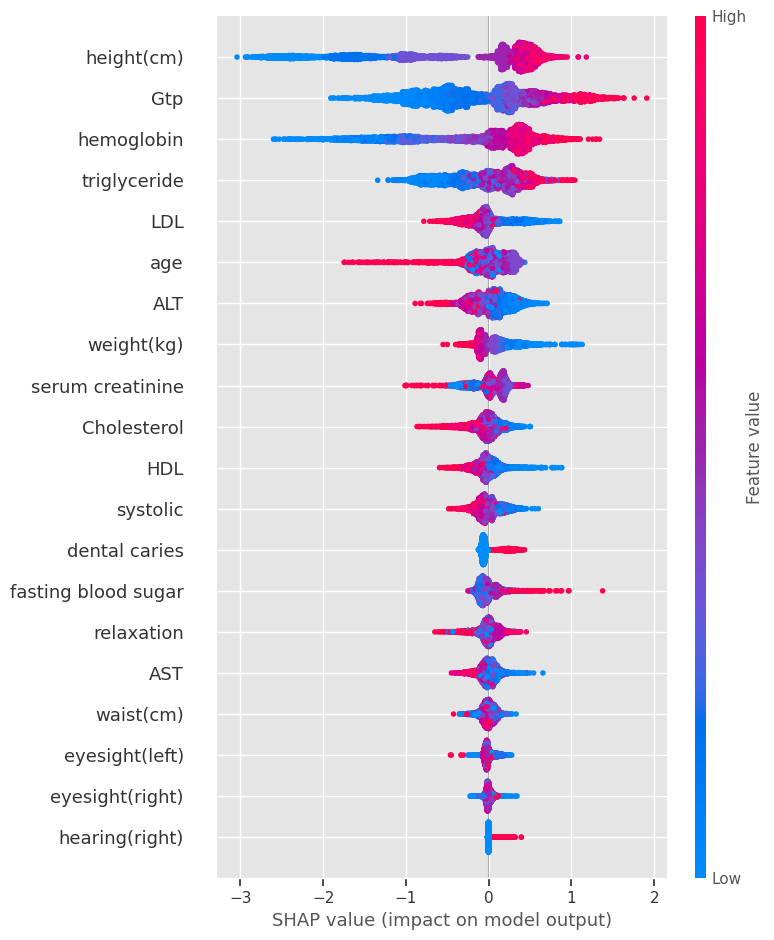

In [19]:
# SHAP no conjunto de dados (amostragem para não pesar demais)
sample_idx = np.random.choice(len(X), size=min(5000, len(X)), replace=False)
X_shap_sample = X.iloc[sample_idx]

explainer = shap.TreeExplainer(importance_model)
shap_values = explainer.shap_values(X_shap_sample)

shap.summary_plot(shap_values, X_shap_sample, show=True)


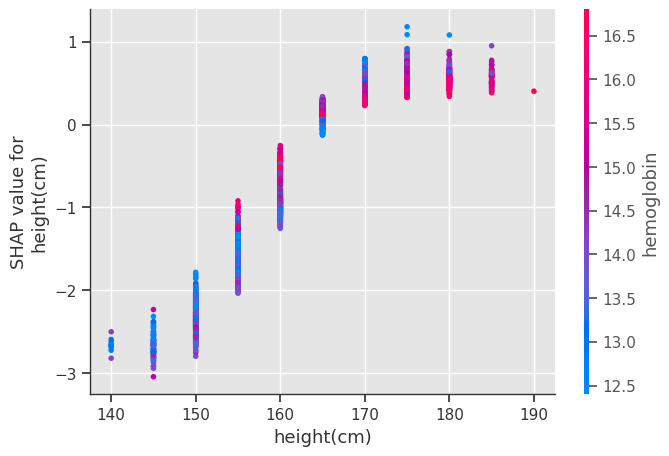

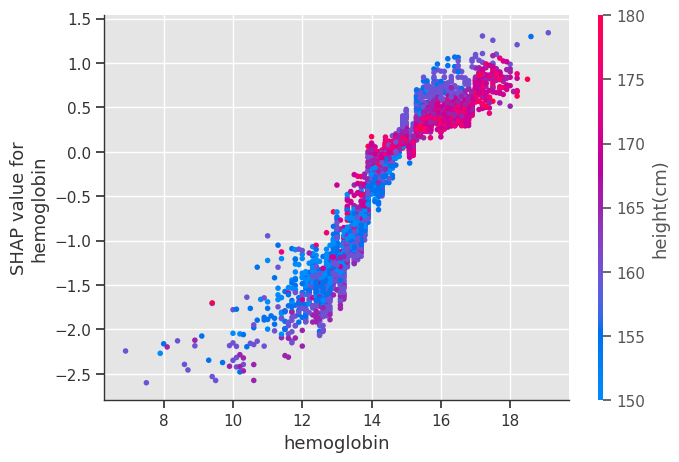

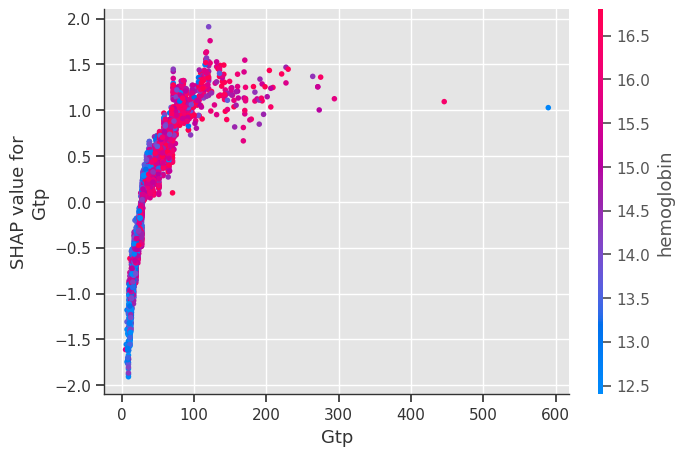

In [20]:
# Dependence plots para as 2-3 features mais importantes
top_features = importances.index[:3].tolist()

for feat in top_features:
    shap.dependence_plot(feat, shap_values, X_shap_sample, show=True)


## 10. Geração da submissão

In [21]:
submission = pd.DataFrame({
    "id": test["id"],
    "smoking": results["test_predictions"],
})

assert list(submission.columns) == list(sample_submission.columns), "Colunas não batem com o sample_submission!"
assert len(submission) == len(sample_submission), "Número de linhas não bate com o sample_submission!"

submission.to_csv("submission_xgboost.csv", index=False)
submission.head()


,id,smoking
0,159256,0.618068
1,159257,0.328076
2,159258,0.375537
3,159259,0.023590
4,159260,0.605956


## 11. Comparação com o leaderboard do Kaggle

Preencher após submeter o `submission_xgboost.csv` na competição:

| Item | Valor |
|---|---|
| AUC out-of-fold (local) | *(preencher com `oof_auc`)* |
| AUC público/privado no Kaggle | *(preencher após submissão)* |
| Posição aproximada no leaderboard | *(preencher)* |
| AUC dos primeiros colocados | *(consultar leaderboard)* |
| Distância para o topo | *(calcular)* |

**Hipóteses sobre estratégias dos competidores melhor ranqueados** (para discutir no relatório):
- Provavelmente usam **ensemble de múltiplos boosters** (XGBoost + LightGBM + CatBoost) via stacking ou blending, não um único modelo.
- Podem incorporar o **dataset "original"** de bio-sinais (mencionado em soluções públicas desta competição) como dado complementar de treino, já que o Playground dataset é sintético/derivado dele.
- Feature engineering mais extensa e/ou mais cuidadosa que a testada por nós (a nossa versão engenheirada teve desempenho levemente inferior à raw, o que já é um resultado interessante para discutir na análise crítica: nem toda engenharia de atributos melhora um modelo baseado em árvores, que já captura não-linearidades e interações sozinho).
